# RelBench rel-stack (Stack Exchange) Dataset Demo

This notebook demonstrates the **RelBench rel-stack dataset processing pipeline**, which converts Stack Exchange relational data into standardized cross-table prediction examples.

**What this does:**
- Loads the pre-processed RelBench rel-stack dataset containing 7 tables (users, posts, comments, badges, postLinks, postHistory, votes)
- Explores 9 FK-link sub-datasets with aligned parent→child feature matrices
- Demonstrates the deterministic fold assignment and example construction logic
- Visualizes cardinality distributions and coverage across FK relationships

**Source:** [RelBench (Stanford SNAP)](https://relbench.stanford.edu/) — Stack Exchange Stats site Q&A data

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed (loguru not needed in notebook — we use print)

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import hashlib
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

Load the pre-processed RelBench rel-stack dataset (mini subset for demo).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/dataset_iter1_download_and_pr/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} FK-link sub-datasets")
print(f"Total examples: {sum(len(ds['examples']) for ds in data['datasets'])}")

Loaded data with 9 FK-link sub-datasets
Total examples: 27


## Configuration

Tunable parameters for the processing pipeline.

In [5]:
# Maximum examples per FK link to process (original: 5000)
MAX_EXAMPLES_PER_LINK = 3

# Number of cross-validation folds for deterministic assignment (original: 5)
N_FOLDS = 5

## Explore Dataset Metadata

The dataset contains schema topology and benchmark task information from the RelBench rel-stack database.

In [6]:
metadata = data["metadata"]
print(f"Source: {metadata['source']}")
print(f"Domain: {metadata['domain']}")
print(f"License: {metadata['license']}")
print(f"Number of tables: {metadata['num_tables']}")
print(f"Number of FK links: {metadata['num_fk_links']}")
print(f"Number of benchmark tasks: {metadata['num_tasks']}")
print(f"\nTable names: {metadata['table_names']}")
print(f"Task names: {metadata['task_names']}")
print(f"\nSchema topology (table -> connected tables):")
for table, connections in metadata["schema_topology"].items():
    print(f"  {table} -> {connections}")

Source: RelBench (Stanford SNAP)
Domain: social/Q&A platform
License: CC BY-SA 4.0
Number of tables: 7
Number of FK links: 11
Number of benchmark tasks: 6

Table names: ['comments', 'badges', 'postLinks', 'postHistory', 'votes', 'users', 'posts']
Task names: ['user-engagement', 'post-votes', 'user-badge', 'user-post-comment', 'post-post-related', 'badges-class']

Schema topology (table -> connected tables):
  comments -> ['posts', 'users']
  users -> ['badges', 'comments', 'postHistory', 'posts', 'votes']
  posts -> ['comments', 'postHistory', 'postLinks', 'posts', 'users', 'votes']
  badges -> ['users']
  postLinks -> ['posts']
  postHistory -> ['posts', 'users']
  votes -> ['posts', 'users']


## Deterministic Fold Assignment

The `make_fold` function assigns each example to a cross-validation fold using an MD5 hash of the row index — ensuring reproducible, balanced splits.

In [7]:
def make_fold(row_idx: int, n_folds: int = 5) -> int:
    """Deterministic fold assignment based on row index hash."""
    h = int(hashlib.md5(str(row_idx).encode()).hexdigest(), 16)
    return h % n_folds

# Demonstrate fold assignment for first 10 rows
print("Row index -> Fold assignment:")
for i in range(10):
    print(f"  Row {i} -> Fold {make_fold(i, N_FOLDS)}")

Row index -> Fold assignment:
  Row 0 -> Fold 0
  Row 1 -> Fold 1
  Row 2 -> Fold 2
  Row 3 -> Fold 3
  Row 4 -> Fold 0
  Row 5 -> Fold 3
  Row 6 -> Fold 2
  Row 7 -> Fold 0
  Row 8 -> Fold 1
  Row 9 -> Fold 4


## Process FK-Link Sub-Datasets

Each FK link produces a sub-dataset where each example has:
- **input**: parent table features (as JSON dict)
- **output**: child table features (as JSON dict)
- **metadata**: fold, cardinality stats, table names, FK column

In [8]:
# Process each FK-link sub-dataset and collect summary statistics
summary_rows = []

for ds in data["datasets"]:
    ds_name = ds["dataset"]
    examples = ds["examples"][:MAX_EXAMPLES_PER_LINK]

    # Extract metadata from first example
    ex0 = examples[0]
    child_table = ex0["metadata_child_table"]
    parent_table = ex0["metadata_parent_table"]
    fkey_col = ex0["metadata_fkey_col"]
    child_feats = ex0["metadata_child_feature_names"]
    parent_feats = ex0["metadata_parent_feature_names"]
    cardinality_mean = ex0["metadata_cardinality_mean"]
    cardinality_median = ex0["metadata_cardinality_median"]
    coverage = ex0["metadata_coverage"]

    # Parse input/output JSON strings to inspect feature values
    parsed_inputs = [json.loads(ex["input"]) for ex in examples]
    parsed_outputs = [json.loads(ex["output"]) for ex in examples]

    summary_rows.append({
        "FK Link": ds_name.replace("rel-stack/", ""),
        "Parent": parent_table,
        "Child": child_table,
        "FK Col": fkey_col,
        "# Parent Feats": len(parent_feats),
        "# Child Feats": len(child_feats),
        "Card. Mean": round(cardinality_mean, 2),
        "Card. Median": cardinality_median,
        "Coverage": round(coverage, 3),
        "# Examples": len(examples),
    })

    print(f"\n--- {ds_name} ---")
    print(f"  {parent_table} ({parent_feats}) -> {child_table} ({child_feats})")
    print(f"  Cardinality: mean={cardinality_mean:.2f}, median={cardinality_median}")
    print(f"  Coverage: {coverage:.3f}")
    print(f"  Example input:  {examples[0]['input']}")
    print(f"  Example output: {examples[0]['output']}")

print(f"\nProcessed {len(summary_rows)} FK-link sub-datasets")


--- rel-stack/badges__UserId__users ---
  users (['ProfileImageUrl']) -> badges (['Class', 'TagBased'])
  Cardinality: mean=3.27, median=2.0
  Coverage: 0.555
  Example input:  {"ProfileImageUrl": 0.0}
  Example output: {"Class": 3.0, "TagBased": 0.0}

--- rel-stack/postLinks__PostId__posts ---
  posts (['PostTypeId']) -> postLinks (['LinkTypeId'])
  Cardinality: mean=1.62, median=1.0
  Coverage: 0.113
  Example input:  {"PostTypeId": 1.0}
  Example output: {"LinkTypeId": 1.0}

--- rel-stack/postLinks__RelatedPostId__posts ---
  posts (['PostTypeId']) -> postLinks (['LinkTypeId'])
  Cardinality: mean=3.04, median=1.0
  Coverage: 0.074
  Example input:  {"PostTypeId": 1.0}
  Example output: {"LinkTypeId": 3.0}

--- rel-stack/postHistory__PostId__posts ---
  posts (['PostTypeId']) -> postHistory (['PostHistoryTypeId'])
  Cardinality: mean=3.52, median=3.0
  Coverage: 1.000
  Example input:  {"PostTypeId": 1.0}
  Example output: {"PostHistoryTypeId": 1.0}

--- rel-stack/postHistory__User

## Summary Table

Overview of all FK-link sub-datasets with their cardinality and coverage statistics.

In [9]:
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

                        FK Link Parent       Child        FK Col  # Parent Feats  # Child Feats  Card. Mean  Card. Median  Coverage  # Examples
          badges__UserId__users  users      badges        UserId               1              2        3.27           2.0     0.555           3
       postLinks__PostId__posts  posts   postLinks        PostId               1              1        1.62           1.0     0.113           3
postLinks__RelatedPostId__posts  posts   postLinks RelatedPostId               1              1        3.04           1.0     0.074           3
     postHistory__PostId__posts  posts postHistory        PostId               1              1        3.52           3.0     1.000           3
     postHistory__UserId__users  users postHistory        UserId               1              1       12.95           3.0     0.333           3
           votes__PostId__posts  posts       votes        PostId               1              1        4.34           2.0     0.829     

## Visualization

Compare cardinality and coverage across FK relationships to understand the relational structure.

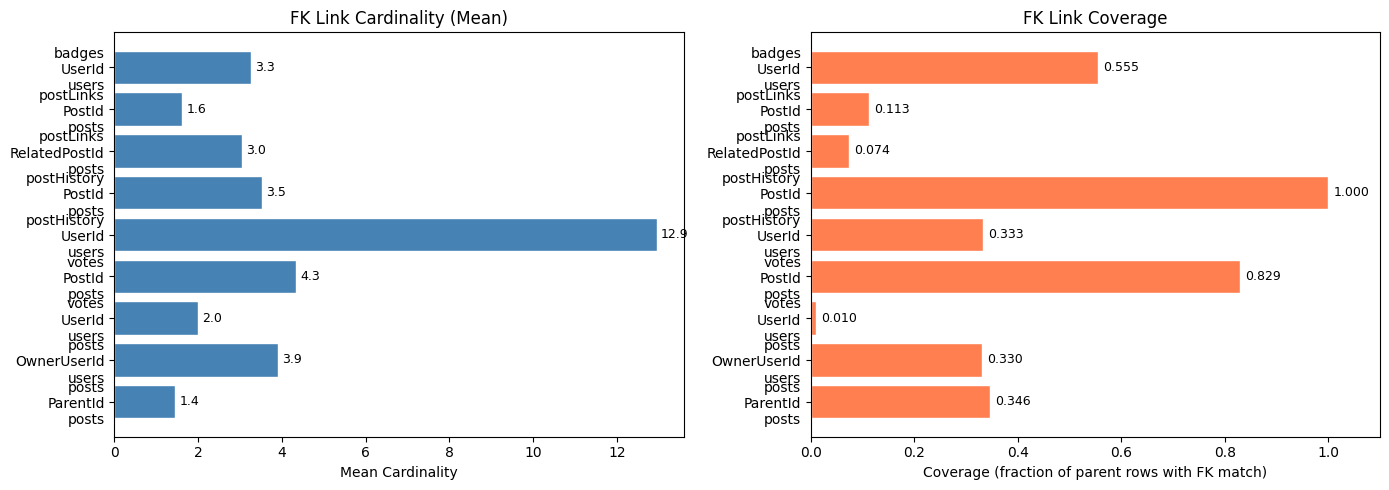

Saved visualization to fk_link_stats.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = df_summary["FK Link"].str.replace("__", "\n", regex=False)

# Plot 1: Cardinality (mean)
ax1 = axes[0]
bars1 = ax1.barh(labels, df_summary["Card. Mean"], color="steelblue", edgecolor="white")
ax1.set_xlabel("Mean Cardinality")
ax1.set_title("FK Link Cardinality (Mean)")
ax1.invert_yaxis()
for bar, val in zip(bars1, df_summary["Card. Mean"]):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", fontsize=9)

# Plot 2: Coverage
ax2 = axes[1]
bars2 = ax2.barh(labels, df_summary["Coverage"], color="coral", edgecolor="white")
ax2.set_xlabel("Coverage (fraction of parent rows with FK match)")
ax2.set_title("FK Link Coverage")
ax2.set_xlim(0, 1.1)
ax2.invert_yaxis()
for bar, val in zip(bars2, df_summary["Coverage"]):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fk_link_stats.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved visualization to fk_link_stats.png")